# Skin / Fabric / Background Dataset

**Goal:** segment **skin** vs. **fabric/clothing** vs. **background** (pixel-level), for the
DINOv3 + dense-decoder segmenter in `pyrafuse/model/model.py`.

The 3-class dataset is built by fusing two datasets that share the same underlying images:

| Dataset | Images | Labels | Role | Source | License |
| --- | --- | --- | --- | --- | --- |
| **Fashionpedia** | 45,623 train / 3,200 val+test | garment instance masks (46 apparel categories) | fabric | [cvdfoundation/fashionpedia](https://github.com/cvdfoundation/fashionpedia) ([download page](https://fashionpedia.github.io/home/Fashionpedia_download.html)) | CC BY-NC |
| **visuAAL** | 46,775 (45.6k train / 1.15k val) | binary skin mask | skin | [Zenodo](https://zenodo.org/records/6973396) | CC BY-NC |

Label convention used everywhere below (`pyrafuse.data.masks.build_label`), with priority
`skin > fabric > background` on overlap (e.g. an arm in front of a sleeve):

| value | class                          |
| ----- | ------------------------------ |
| 0     | background                     |
| 1     | fabric (Fashionpedia garments) |
| 2     | skin (visuAAL)                 |

Data layout under `data/` (built/downloaded by [`scripts/prepare_data.py`](../scripts/prepare_data.py)):

```
data/raw/
  instances_attributes_{train,val}2020.json   # Fashionpedia annotations
  train/<id>.jpg                              # Fashionpedia train images
  test/<id>.jpg                               # Fashionpedia val+test images (val labels pair with this dir)
  visuaal/visuAAL Skin Segmentation Dataset/{train,val}_masks/<id>.jpg
data/processed/
  train_labels/<id>.png                       # fused 3-class masks (built, not downloaded)
  val_labels/<id>.png
```


---

## 1. Why visuAAL + Fashionpedia

**visuAAL** was *derived from Fashionpedia*, a fashion/garment dataset, so its subjects are
heavily clothed and its masks specifically separate **skin from clothing**. This forces the
model to learn the hard skin/fabric boundary (sleeves, necklines, hems) that generic
face/hand skin datasets never show.

- **46,775 images** total — 45,623 train / 1,152 val, pixel-level skin masks.
- Masks are **binary** (skin / not-skin); "not-skin" = fabric + background.
- Masks are auto-generated (weakly supervised from body+hair+garment segmentation) so they're
  slightly noisy at edges — fine for a DINOv3 dense head; evaluate crisp boundaries on
  Pratheepan/ECU separately.
- Not every Fashionpedia image has a visuAAL skin mask (images without people were dropped),
  so the pipeline drives everything off the **skin mask** filenames, not the image filenames.

**Paper:** *From Garment to Skin: The visuAAL Skin Segmentation Dataset* (ICIAP 2022 Workshops).


---

## 2. Setup

`%autoreload` picks up edits to `pyrafuse/` without restarting the kernel.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import torch
from torch.utils.data import DataLoader

from pyrafuse.data import (
    SkinFabricDataset, build_split, NUM_CLASSES,
    BACKGROUND, FABRIC, SKIN,
)

DATA = Path("../data")
RAW, PROC = DATA / "raw", DATA / "processed"
print("classes:", NUM_CLASSES, "->", {BACKGROUND: "bg", FABRIC: "fabric", SKIN: "skin"})

classes: 3 -> {0: 'bg', 1: 'fabric', 2: 'skin'}


### Download & build the data (idempotent)

[`scripts/prepare_data.py`](../scripts/prepare_data.py) fetches whatever is missing and (re)builds
the fused labels — each step checks its own output first and skips itself if it already looks
complete, so this is safe and fast to re-run:

1. Fashionpedia annotations (`instances_attributes_{train,val}2020.json`)
2. Fashionpedia images (`raw/train/`, `raw/test/`)
3. visuAAL skin masks (`raw/visuaal/`)
4. fused 3-class labels (`processed/{train,val}_labels/`)

Run it once before using the cells below. Pass `--only <step>`, `--force`, or `--limit N`
(smoke test) as needed — see `python ../scripts/prepare_data.py --help`.


In [2]:
!python ../scripts/prepare_data.py

[annotations]
  already present, skipping (use --force to redo)
[images]


  already present, skipping (use --force to redo)
[visuaal-masks]


  already present, skipping (use --force to redo)
[labels]


  already present, skipping (use --force to redo)

done.


### Fine-grained / manual label building

Equivalent CLI for just the label-fusion step: `python -m pyrafuse.data --split val`.
Useful for a quick smoke test (`limit=`) or to rebuild labels after changing `masks.py`
without re-downloading anything.


In [3]:
# Uncomment to (re)generate just the labels. `limit` is handy for a quick smoke test.
# build_split("val", limit=50, raw_dir=RAW, processed_dir=PROC)
# build_split("train", raw_dir=RAW, processed_dir=PROC)

---

## 3. Datasets & dataloaders

Note the **val images come from `raw/test/`** (Fashionpedia ships val+test images together;
only the val subset has fused labels).


In [4]:
SIZE = 512  # multiple of 16 for the DINOv3 patch grid

train_ds = SkinFabricDataset(RAW / "train", PROC / "train_labels", size=SIZE)
val_ds = SkinFabricDataset(RAW / "test",  PROC / "val_labels",   size=SIZE)
print(f"train: {len(train_ds)}  val: {len(val_ds)}")

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False,
                        num_workers=4, pin_memory=True)

batch = next(iter(val_loader))
print("image", tuple(batch["image"].shape), batch["image"].dtype)
print("label", tuple(batch["label"].shape), batch["label"].dtype,
      "classes present:", batch["label"].unique().tolist())

train: 44783  val: 1157


image (8, 3, 512, 512) torch.float32
label (8, 512, 512) torch.int64 classes present: [0, 1, 2]


---

## 4. Sanity-check visualisation


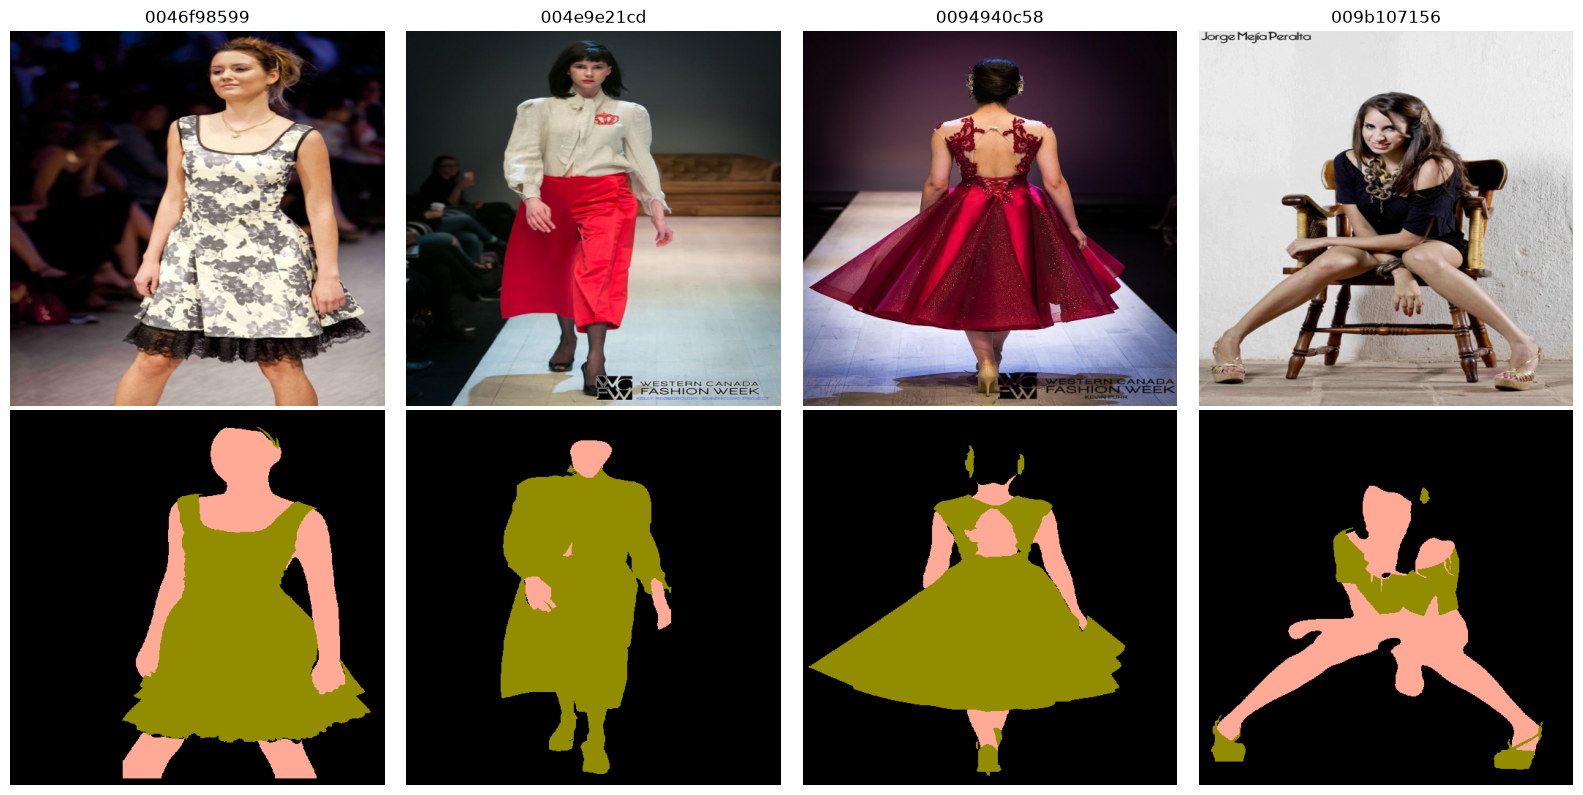

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pyrafuse.data.dataset import IMAGENET_MEAN, IMAGENET_STD

mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std = np.array(IMAGENET_STD).reshape(3, 1, 1)
# class colours: bg=black, fabric=orange, skin=pink
palette = np.array([[0, 0, 0], [145, 140, 0], [255, 170, 150]], dtype=np.uint8)

n = 4
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
for i in range(n):
    s = val_ds[i]
    img = (s["image"].numpy() * std + mean).clip(0, 1).transpose(1, 2, 0)
    axes[0, i].imshow(img)
    axes[0, i].set_title(s["stem"][:10])
    axes[0, i].axis("off")
    axes[1, i].imshow(palette[s["label"].numpy()])
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("image")
axes[1, 0].set_ylabel("label")
plt.tight_layout()
plt.show()

---

## 5. Class balance (for weighted loss)

Skin is the rarest class; you'll likely want class weights or focal loss when training.


In [6]:
counts = torch.zeros(NUM_CLASSES, dtype=torch.long)
for s in val_ds:
    counts += torch.bincount(s["label"].flatten(), minlength=NUM_CLASSES)
frac = counts.float() / counts.sum()
for name, c, f in zip(["background", "fabric", "skin"], counts.tolist(), frac.tolist()):
    print(f"{name:>10}: {c:>12,}  ({f:.3f})")

# inverse-frequency weights, normalised to mean 1
weights = (1.0 / frac)
weights = weights / weights.mean()
print("\nsuggested CE weights:", weights.tolist())

background:  243,184,773  (0.802)
    fabric:   44,722,775  (0.147)
      skin:   15,393,060  (0.051)

suggested CE weights: [0.13491669297218323, 0.7336236238479614, 2.1314597129821777]


---

## 6. Skin tone analysis

Extract per-image skin-pixel RGB statistics using the skin mask (label == 2).
We characterise each image by its median hue and lightness in HSV space, then
cluster the distribution to get a rough Fitzpatrick-scale proxy.


In [7]:
import colorsys
from tqdm.auto import tqdm

mean_np = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std_np = np.array(IMAGENET_STD).reshape(3, 1, 1)


def skin_hsv_stats(sample):
    """Return median HSV + RGB stats for skin pixels, or None if no skin present."""
    img = (sample["image"].numpy() * std_np + mean_np).clip(0, 1)  # (3,H,W)
    mask = sample["label"].numpy() == SKIN                            # (H,W)
    if mask.sum() == 0:
        return None
    pixels = img[:, mask].T   # (N, 3) RGB in [0,1]
    hsv = np.array([colorsys.rgb_to_hsv(*p) for p in pixels])
    return {
        "stem":  sample["stem"],
        "hue":   float(np.median(hsv[:, 0])),
        "sat":   float(np.median(hsv[:, 1])),
        "val":   float(np.median(hsv[:, 2])),
        "r":     float(np.median(pixels[:, 0])),
        "g":     float(np.median(pixels[:, 1])),
        "b":     float(np.median(pixels[:, 2])),
        "n_px":  int(mask.sum()),
    }


records = [r for s in tqdm(train_ds, desc="skin-tone stats")
           if (r := skin_hsv_stats(s))]
print(f"{len(records)} / {len(train_ds)} images have skin pixels")

skin-tone stats:   0%|          | 0/44783 [00:00<?, ?it/s]

42353 / 44783 images have skin pixels


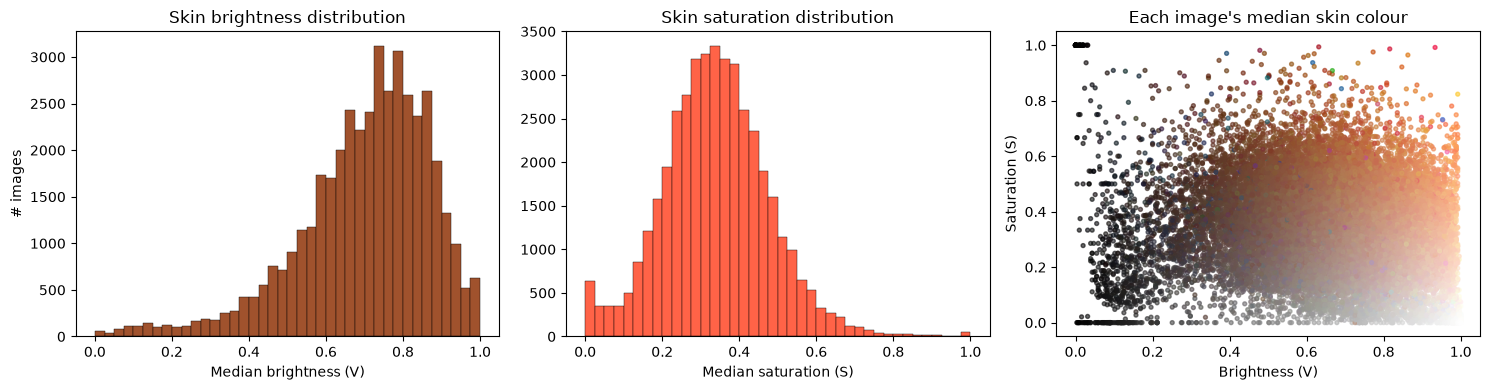

             val        sat        hue          r          g          b
count  42353.000  42353.000  42353.000  42353.000  42353.000  42353.000
mean       0.701      0.341      0.116      0.698      0.533      0.461
std        0.171      0.137      0.194      0.174      0.158      0.159
min        0.000      0.000      0.000      0.000      0.000      0.000
25%        0.612      0.253      0.048      0.612      0.439      0.357
50%        0.729      0.337      0.058      0.725      0.545      0.463
75%        0.824      0.425      0.071      0.824      0.635      0.565
max        1.000      1.000      0.989      1.000      1.000      1.000


In [8]:
import pandas as pd

df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["val"], bins=40, color="sienna", edgecolor="k", linewidth=0.3)
axes[0].set_xlabel("Median brightness (V)")
axes[0].set_ylabel("# images")
axes[0].set_title("Skin brightness distribution")

axes[1].hist(df["sat"], bins=40, color="tomato", edgecolor="k", linewidth=0.3)
axes[1].set_xlabel("Median saturation (S)")
axes[1].set_title("Skin saturation distribution")

# Scatter: brightness vs saturation, coloured by median RGB
colors = np.stack([df["r"], df["g"], df["b"]], axis=1).clip(0, 1)
axes[2].scatter(df["val"], df["sat"], c=colors, s=8, alpha=0.6)
axes[2].set_xlabel("Brightness (V)")
axes[2].set_ylabel("Saturation (S)")
axes[2].set_title("Each image's median skin colour")

plt.tight_layout()
plt.show()

print(df[["val", "sat", "hue", "r", "g", "b"]].describe().round(3))

Images per Fitzpatrick-proxy group (I=lightest, VI=darkest):
fitzpatrick_proxy
1     8350
2    12067
3    10662
4     6738
5     3270
6     1266


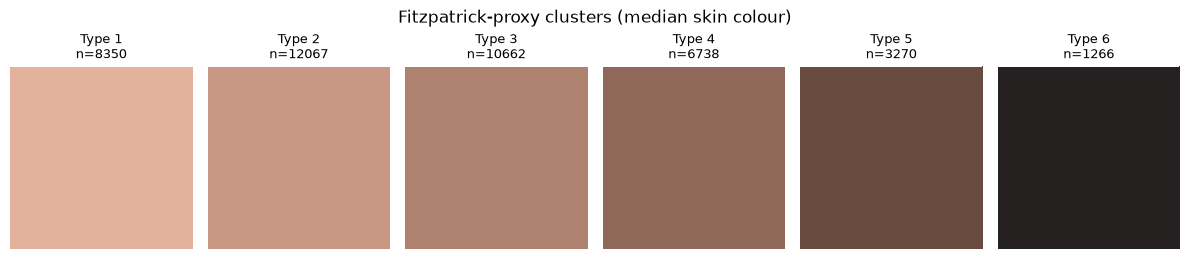

In [9]:
from sklearn.cluster import KMeans

# Cluster on brightness (V) only — the primary Fitzpatrick axis.
# 6 clusters ≈ Fitzpatrick types I–VI (light → dark).
N_TONES = 6
km = KMeans(n_clusters=N_TONES, random_state=0, n_init="auto")
df["tone"] = km.fit_predict(df[["val"]])

# Re-label clusters I–VI from lightest to darkest
order = km.cluster_centers_[:, 0].argsort()[::-1]  # descending brightness
remap = {old: new for new, old in enumerate(order)}
df["fitzpatrick_proxy"] = df["tone"].map(remap) + 1  # 1-indexed

counts_by_tone = df["fitzpatrick_proxy"].value_counts().sort_index()
print("Images per Fitzpatrick-proxy group (I=lightest, VI=darkest):")
print(counts_by_tone.to_string())

# Visualise: one swatch per cluster showing the mean skin colour
fig, axes = plt.subplots(1, N_TONES, figsize=(N_TONES * 2, 2.5))
for tone_id in range(1, N_TONES + 1):
    sub = df[df["fitzpatrick_proxy"] == tone_id]
    swatch = np.array([[sub[["r", "g", "b"]].median().values.clip(0, 1)]])
    axes[tone_id - 1].imshow(swatch)
    axes[tone_id - 1].set_title(f"Type {tone_id}\nn={len(sub)}", fontsize=9)
    axes[tone_id - 1].axis("off")
plt.suptitle("Fitzpatrick-proxy clusters (median skin colour)", y=1.02)
plt.tight_layout()
plt.show()